## Evaluate All Methods with Solutions

### Manage Packages

In [1]:
import ray
ray.shutdown()

In [1]:
# Import all required packages
import pandas as pd                   # For data manipulation and analysis
import io
import gymnasium as gym
import numpy as np
import os
import pickle
import copy
import random
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.ticker as ticker
import warnings
from concurrent.futures import ProcessPoolExecutor
import multiprocessing
import torch
import networkx as nx
from tqdm import tqdm
from scipy.stats import ttest_ind
import seaborn as sns

# Import custom zero counting function
def count_zeros(arr):
    return np.count_nonzero(arr < 0.00001)

# Import custom environment .py file
import env_TA as ce 

### Input Parameters

In [ ]:
##### User Determined Settings
graphName = "UKR"  # Graph nodes and edges to use
env_params = {'deterministic_agent': False,
              'multiple_interdiction_attempts': False,
              'attacker_strategy': 'zero_sum',  # canalize   isolate   divert  zero_sum
              'training_budget_range': (12, 24),  #G5x5: zero_sum/isolate: (5,15), canalize/divert: (12,24) G10x10: zero_sum/isolate: (15,30), canalize/divert: (20,40)   #UKR: zero_sum/isolate: (10,20), canalize/divert: (18,30)
              'max_path_length': 2,  #G5x5: 2,  G10x10: 3, UKR: 4
              'sample_size': None,
              'penalty_value': -0.01,
             }

solution_name = 'v03_06_bi'

method_type = 'Max-Flow_Heuristic'  # 'RL' 'Alternate_Solution' 'Max-Flow_Heuristic', 'Min-Cut_Heuristic' or 'Baycik'

#'RL' Settings
if method_type == 'RL':
    model_name = "G5x5_S_MaskablePPO_divert_B_v03_04"
    model_timesteps = 10000000 # Set a number or  None
    RL_classify = False

elif method_type == 'Alternate_Solution': #'Alternate_Solution' Settings
    alt_solution_name = 'v03_06_opt_m'
    model_name = f"Solution {alt_solution_name}"

elif method_type == 'Max-Flow_Heuristic':
    model_name = "Max-Flow_Heuristic Solution"

elif method_type == 'Min-Cut_Heuristic':
    model_name = "Min-Cut_Heuristic Solution"

elif method_type == 'Baycik':
    model_name = "Baycik Solution"
    baycik_training_solution_name = solution_name
    baycik_training_indices = (500, 3500) # Start and end index for training episodes

### Create Environment, Agent, and Load Optimal Solutions

In [9]:
## Create Environment
# Create nodes and edges
node_filename = f"{graphName}_Nodes.csv"  # Dynamically include graphName
edge_filename = f"{graphName}_Edges.csv"  # Dynamically include graphName

nodes, edges = ce.create_nodes_edges(node_filename, edge_filename)

# Load Environment
env = ce.CustomEnv(nodes, edges, **env_params)

# Get the current recovering directory
current_dir = os.getcwd()

# Determine Model Path if using RL
if method_type == 'RL': 
    models_dir = os.path.join(current_dir, '..', 'Trained_RL_Models')

    # LOAD Previous saved model
    if model_timesteps == None:
        model_path = f"{models_dir}/{model_name}/best_model"
    else:    model_path = f"{models_dir}/{model_name}/{model_name}_{model_timesteps}_steps"
    data = np.load(f"{models_dir}/{model_name}/evaluations.npz")

    # Load the model
    if "MaskablePPO" in model_name:
        from sb3_contrib import MaskablePPO
        agent=MaskablePPO.load(model_path,)

## Load Optimal Solutions for Comparison
if env_params['multiple_interdiction_attempts'] == True:
    MI_letter = 'M'
else:
    MI_letter = 'B'

#load and Read Pickle File of Solutions
# Use the same path and filename as in your saving code
save_filename = f"{graphName}_{env_params['attacker_strategy']}_{MI_letter}_solution_{solution_name}.pkl"   

save_path = os.path.join(current_dir, '..', 'Solutions', save_filename)

# Open the pickle file in binary read mode and load the data
with open(save_path, "rb") as f:
    results = pickle.load(f)

# Now you can access the saved data
print("Solution Stats")
print("Episodes completed:", results["last_episode"] + 1)
print("Mean Objective values:", np.mean(results["optimal_obj_vals"][0:500]))
#print("Interdiction sets:", results["all_optimal_interdiction_edges"])
print("Mean Solution times:", np.mean(results["optimal_solution_times"][0:500]))

optimal_obj_vals = results["optimal_obj_vals"]
all_optimal_interdiction_edges = results["all_optimal_interdiction_edges"]
optimal_solution_times = results["optimal_solution_times"]
all_states = results['states']

if method_type == 'Alternate_Solution':
    alt_save_filename = f"{graphName}_{env_params['attacker_strategy']}_{MI_letter}_solution_{alt_solution_name}.pkl"   

    alt_save_path = os.path.join(current_dir, '..', 'Solutions', alt_save_filename)

    # Open the pickle file in binary read mode and load the data
    with open(alt_save_path, "rb") as f:
        alt_results = pickle.load(f)

    # Now you can access the saved data
    print()
    print("Alternate Solution Stats")
    print("Episodes completed:", alt_results["last_episode"] + 1)
    print("Mean Objective values:", np.mean(alt_results["optimal_obj_vals"][0:500]))
    #print("Interdiction sets:", alt_results["all_optimal_interdiction_edges"])
    print("Mean Solution times:", np.mean(alt_results["optimal_solution_times"][0:500]))

    alt_optimal_obj_vals = alt_results["optimal_obj_vals"]
    alt_all_optimal_interdiction_edges = alt_results["all_optimal_interdiction_edges"]
    alt_optimal_solution_times = alt_results["optimal_solution_times"]
    alt_all_states = alt_results['states']

# Train Baycik Model if selected
if method_type == 'Baycik':
    baycik_training_filename = f"{graphName}_{env_params['attacker_strategy']}_{MI_letter}_solution_{baycik_training_solution_name}.pkl"
    baycik_training_path = os.path.join(current_dir, '..', 'Solutions', baycik_training_filename)
    
    # Reset env to ensure state is initialized before training
    env.reset()
    
    # Train the model
    print(f"Training Baycik model on {baycik_training_filename} (Indices: {baycik_training_indices})...")
    baycik_model = env.train_baycik_model(baycik_training_path, 
                                          start_index=baycik_training_indices[0], 
                                          end_index=baycik_training_indices[1])
    print("Baycik Model Trained.")

Solution Stats
Episodes completed: 542
Mean Objective values: 100.5297694215822
Mean Solution times: 524.662987601419


In [14]:
start = 0
end = start+1
end = 6
print('Optimal Objs: ',optimal_obj_vals[start:end])
print('Optimal Times: ', optimal_solution_times[start:end])
print('Optimal Actions: ',all_optimal_interdiction_edges[start:end])

Optimal Objs:  [220.09240339 232.48481175 197.10000033 279.01279828 190.79733081
 187.90000323]
Optimal Times:  [7496.669767417945, 2442.056933579035, 541.0673926700838, 650.9734499910846, 624.2976315519772, 610.4283447260968]
Optimal Actions:  [[(2, 12), (4, 14), (6, 16), (8, 18), (9, 19), (11, 21)], [(43, 53), (44, 54), (45, 55), (48, 58), (49, 59), (50, 60)], [(82, 92), (83, 93), (86, 96), (87, 97), (88, 98)], [(64, 74), (65, 75), (71, 81), (73, 74)], [(52, 62), (53, 63), (54, 64), (57, 67), (59, 69), (60, 70), (61, 71)], [(2, 12), (4, 14), (5, 15), (6, 16), (7, 17), (8, 18), (10, 20)]]


## Analysis

### Code

In [6]:
#Training Analysis Plot
def plot_training_curve(data, model_name, figsize=(6, 3.4), xlim=(0, 5000000), ylim=(0, 5), 
                       xlabel='Training Step', ylabel='Mean Step Reward', 
                       title=None, x_tick_interval=1000000, show_legend=True):
    """
    Plot training curve with consistent formatting for reinforcement learning results
    
    Parameters:
    - data: Dictionary containing 'timesteps' and 'results' keys
    - model_name: String label for the plotted line
    - figsize: Tuple for figure size (width, height)
    - xlim: Tuple for x-axis limits (min, max)
    - ylim: Tuple for y-axis limits (min, max)
    - xlabel: String for x-axis label
    - ylabel: String for y-axis label
    - title: String for plot title (optional)
    - x_tick_interval: Integer for x-axis tick spacing
    - show_legend: Boolean to show/hide legend
    """
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    import numpy as np
    import seaborn as sns
    
    plt.figure(figsize=figsize)
    
    # Set consistent formatting
    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 14,
        'axes.titlesize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
    })
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.family'] = 'STIXGeneral'
    
    # Extract data and compute mean rewards
    timesteps = data['timesteps']
    results = data['results']
    mean_rewards = np.mean(results, axis=1)
    
    # Plot the training curve
    plt.plot(timesteps, mean_rewards, label=model_name)
    
    # Set labels and title
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if title:
        plt.title(title)
    
    # Show legend if requested
    if show_legend:
        plt.legend()
    
    # Set axis limits
    plt.xlim(xlim[0], xlim[1])
    plt.ylim(ylim[0], ylim[1])
    
    # Set x-axis ticks at specified intervals
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(x_tick_interval))
    
    # Format x-axis tick labels with commas
    def format_func(value, tick_number):
        return f"{value:,.0f}"
    
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    
    # Apply clean styling
    sns.despine()
    plt.show()

import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

#Optimal Interdicted Edge Histogram
def plot_edge_histogram_from_lists(edge_lists, title="Interdicted Edge Frequency Histogram", figsize=(12, 6), 
                                 combine_all=True, show_individual=False):
    """
    Create a histogram from a list of lists of edges showing frequency of occurrence.
    
    Parameters:
    edge_lists: List of lists, where each inner list contains edge tuples
                e.g., [[(1,2), (2,3)], [(1,2), (3,4)], [(2,3), (1,2)]]
    title: Title for the plot
    figsize: Figure size (width, height)
    combine_all: If True, combines all edges from all lists into one histogram
    show_individual: If True, shows separate histograms for each list
    
    Returns:
    Dictionary with frequency data
    """
    
    if combine_all:
        # Flatten all edge lists into one big list
        all_edges = []
        for edge_list in edge_lists:
            all_edges.extend(edge_list)
        
        # Count occurrences of each edge across all lists
        edge_counts = Counter(all_edges)
        
        # Sort edges for consistent ordering
        sorted_edges = sorted(edge_counts.keys())
        counts = [edge_counts[edge] for edge in sorted_edges]
        edge_labels = [f"({edge[0]},{edge[1]})" for edge in sorted_edges]
        
        # Create the bar plot
        plt.figure(figsize=figsize)
        bars = plt.bar(range(len(edge_labels)), counts, alpha=0.7, color='steelblue')
        
        # Customize the plot
        plt.xlabel('Edges')
        plt.ylabel('Total Frequency Across 1,000 Episodes')
        plt.title(f"{title}")
        plt.xticks(range(len(edge_labels)), edge_labels, rotation=45, ha='right')
        
        # Add value labels on top of bars
        for bar, count in zip(bars, counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    str(count), ha='center', va='bottom')
        
        plt.tight_layout()
        plt.grid(axis='y', alpha=0.3)
        plt.show()
        
        return {"combined": edge_counts, "total_edges": len(all_edges), "num_lists": len(edge_lists)}

#Heatmap of Interdicted Edges on Graph
def plot_graph_with_node_types(nodes, edges, interdiction_counts, 
                               title="Network Graph with Node Types and Interdiction Counts", 
                               figsize=(12, 6), colormap='Reds'):
    """
    Enhanced plotting function that colors nodes by type and edges by interdiction counts
    
    Parameters:
    - nodes: Dictionary of Node objects
    - edges: Dictionary of Edge objects  
    - interdiction_counts: Dictionary with edge keys and count values
    - title: Graph title
    - figsize: Figure size
    - colormap: Matplotlib colormap for edge coloring ('Reds', 'Blues', 'viridis', etc.)
    """
    import matplotlib.cm as cm
    from matplotlib.colors import Normalize
    
    # Create NetworkX graph
    G = nx.DiGraph()
    
    # Add nodes and edges
    for node_id, node_obj in nodes.items():
        G.add_node(node_id, 
                   pos=(node_obj.xpos, node_obj.ypos),
                   node_type=node_obj.node_type)
    
    for edge_id, edge_obj in edges.items():
        origin, destination = edge_id
        # Get interdiction count for this edge (default to 0 if not found)
        count = interdiction_counts.get(edge_id, 0)
        G.add_edge(origin, destination, 
                   interdictable=edge_obj.interdictable,
                   interdiction_count=count)
    
    plt.figure(figsize=figsize)
    pos = nx.get_node_attributes(G, 'pos')
    
    # Get unique node types and assign colors
    node_types = nx.get_node_attributes(G, 'node_type')
    # Define the order you want in the legend
    desired_order = ['source', 'intermediate', 'sink']
    
    # Filter to only include types that actually exist in your graph
    available_types = set(node_types.values())
    ordered_types = [node_type for node_type in desired_order if node_type in available_types]
    
    # Assign colors to node types in the specified order (swapped source and intermediate)
    colors = plt.cm.Set3(np.linspace(0, 1, len(ordered_types)))
    # Create color mapping with source and intermediate colors swapped
    if len(ordered_types) >= 2:
        # Swap colors for source and intermediate
        color_list = list(colors)
        if 'source' in ordered_types and 'intermediate' in ordered_types:
            source_idx = ordered_types.index('source')
            intermediate_idx = ordered_types.index('intermediate')
            color_list[source_idx], color_list[intermediate_idx] = color_list[intermediate_idx], color_list[source_idx]
        type_color_map = dict(zip(ordered_types, color_list))
    else:
        type_color_map = dict(zip(ordered_types, colors))
    
    # Draw nodes colored by type in the specified order
    for node_type in ordered_types:
        node_list = [node for node, ntype in node_types.items() if ntype == node_type]
        nx.draw_networkx_nodes(G, pos,
                              nodelist=node_list,
                              node_color=[type_color_map[node_type]],
                              node_size=500,
                              alpha=0.9,
                              label=f'{node_type.title()}')  # Capitalize first letter
    
    # Prepare edge coloring based on interdiction counts
    interdictable_edges = [(u, v) for u, v, d in G.edges(data=True) if d['interdictable']]
    non_interdictable_edges = [(u, v) for u, v, d in G.edges(data=True) if not d['interdictable']]
    
    # Get interdiction counts for interdictable edges
    if interdictable_edges:
        edge_counts = [G[u][v]['interdiction_count'] for u, v in interdictable_edges]
        
        # Handle case where all counts are zero
        if max(edge_counts) > 0:
            # Normalize counts for colormap
            norm = Normalize(vmin=0, vmax=max(edge_counts))
            cmap = mpl.colormaps[colormap]  #cm.get_cmap(colormap)  
            edge_colors = [cmap(norm(count)) for count in edge_counts]
            
            # Draw interdictable edges with color based on counts
            nx.draw_networkx_edges(G, pos, 
                                  edgelist=interdictable_edges,
                                  edge_color=edge_colors,
                                  width=5,
                                  alpha=0.8,
                                  arrows=False)
            
            # Add colorbar for edge counts with decreased horizontal spacing
            sm = cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8, pad=0.02)  # Changed pad from 0.1 to 0.02
            cbar.set_label('Interdiction Count', rotation=270, labelpad=15)
            
        else:
            # All counts are zero, draw in default color
            nx.draw_networkx_edges(G, pos, 
                                  edgelist=interdictable_edges,
                                  edge_color='lightcoral',
                                  width=5,
                                  alpha=0.7,
                                  arrows=True)
    
    # Draw non-interdictable edges in gray
    if non_interdictable_edges:
        nx.draw_networkx_edges(G, pos, 
                              edgelist=non_interdictable_edges,
                              edge_color='gray',
                              width=5,
                              alpha=0.5,
                              arrows=False)
    
    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    
    # Create legend with increased line spacing
    legend = plt.legend(scatterpoints=1, loc='upper left', 
                        labelspacing=1.5)    
    legend.set_frame_on(False)  # Enable legend frame
    legend.get_frame().set_facecolor('white')  # Set background color
    legend.get_frame().set_alpha(0.9)  # Set transparency
    
    # Increase spacing between legend entries
    for i, text in enumerate(legend.get_texts()):
        text.set_verticalalignment('center')
    
    # Adjust legend spacing by modifying the legend properties
    plt.setp(legend.get_texts(), fontsize=12)  # Optional: adjust font size   
    plt.tight_layout()
    
    # Print statistics
    total_interdictions = sum(interdiction_counts.values())
    max_count = max(interdiction_counts.values()) if interdiction_counts else 0
    print(f"\nInterdiction Statistics:")
    print(f"- Total interdictions across all edges: {total_interdictions}")
    print(f"- Maximum interdictions on single edge: {max_count}")
    print(f"- Number of edges with interdictions: {sum(1 for count in interdiction_counts.values() if count > 0)}")
    
    plt.show()
    return G

### Plots

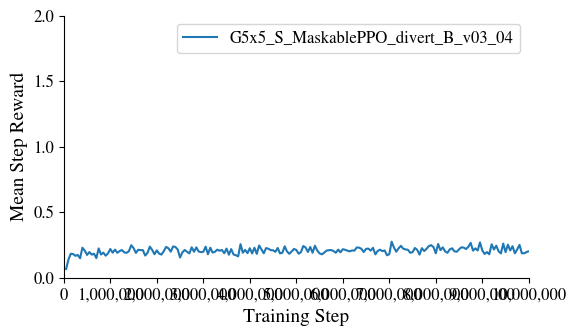

In [7]:
plot_training_curve(data, model_name, xlim=(0, 10000000), ylim=(0, 2), x_tick_interval=1000000)

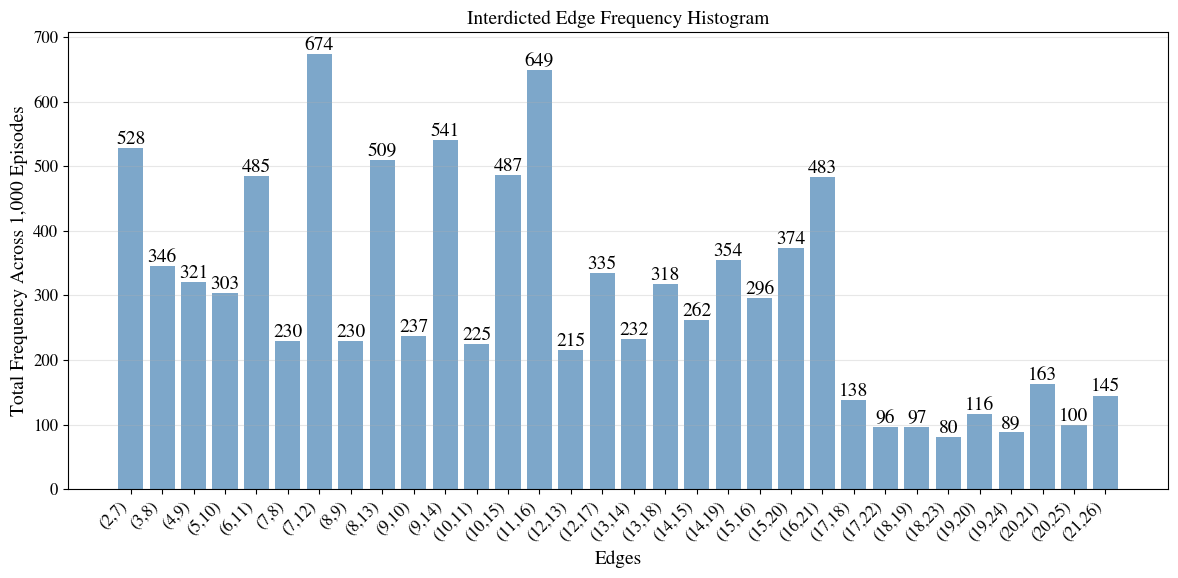

In [8]:
your_edge_lists = all_optimal_interdiction_edges
plots = plot_edge_histogram_from_lists(your_edge_lists)
interdiction_counts=plots['combined']


Interdiction Statistics:
- Total interdictions across all edges: 9658
- Maximum interdictions on single edge: 674
- Number of edges with interdictions: 32


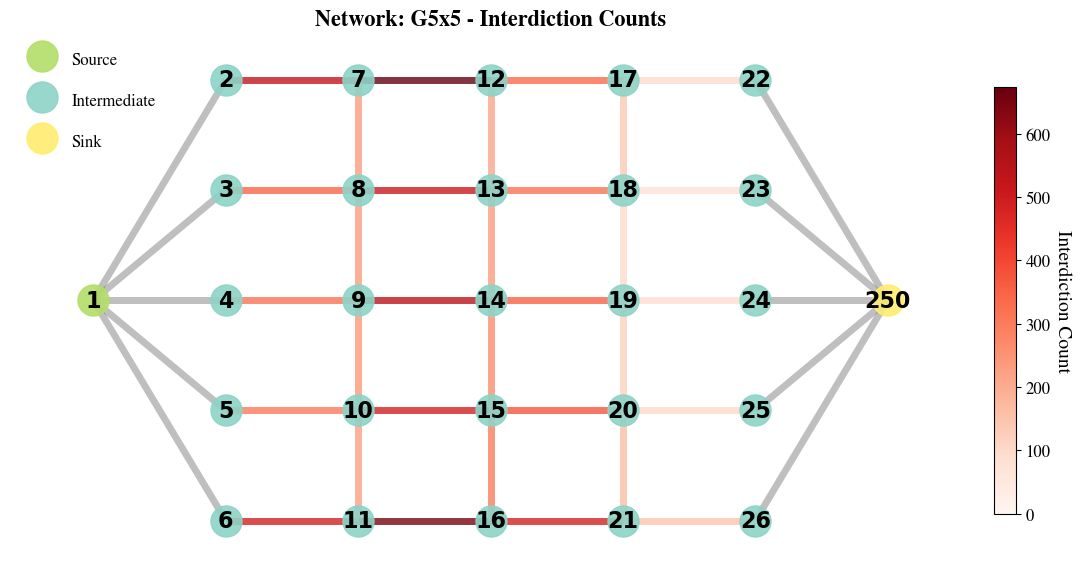

In [9]:
if __name__ == "__main__":
    # Plot with edge colors based on interdiction counts
    G = plot_graph_with_node_types(nodes, edges, interdiction_counts, 
                                   title=f"Network: {graphName} - Interdiction Counts")

### Evaluate Performance Against Optimal Solution

In [ ]:
# Test Agent against a range of scenarios
num_of_scenarios = 500
# Pre-compute constants outside the loop
interdictable_edges_list = list(env.both_edges)

# Initialize arrays to store results
reference_objs =  np.zeros(num_of_scenarios)
agent_best_rewards = np.zeros(num_of_scenarios)
start_flows = np.zeros(num_of_scenarios)
end_flows = np.zeros(num_of_scenarios)
budgets = np.zeros(num_of_scenarios)

# Pre-size list for agent actions instead of appending
all_agent_actions = [None] * num_of_scenarios
agent_solution_times = np.zeros(num_of_scenarios)
uniterdicted_flow = np.zeros(num_of_scenarios)
max_flow_left = np.zeros(num_of_scenarios)

if method_type == 'RL': 
    agent.policy.eval()

# Variables for tracking RL_classify stats
total_rl_actions_all = 0
overlap_min_cut = 0
overlap_max_flow = 0
overlap_adj_min_cut = 0
overlap_adj_max_flow = 0
overlap_other = 0

# Arrays for tracking RL_classify stats per episode
rl_actions_count = np.zeros(num_of_scenarios)
overlap_min_cut_count = np.zeros(num_of_scenarios)
overlap_max_flow_count = np.zeros(num_of_scenarios)
overlap_adj_min_cut_count = np.zeros(num_of_scenarios)
overlap_adj_max_flow_count = np.zeros(num_of_scenarios)
overlap_other_count = np.zeros(num_of_scenarios)
    
for episode in tqdm(range(num_of_scenarios)):
    
    env_state = copy.deepcopy(all_states[episode][0])
    # Pass a deepcopy to avoid the environment mutating the stored env_state
    obs, _ = env.load_network_from_state(episode, copy.deepcopy(env_state))

    budgets[episode] = env.state['budget'][0]
    if env_params['attacker_strategy'] == 'divert':
        start_flows[episode] = env.reference_start_flows[0]
        end_flows[episode] = env.reference_start_flows[1]
    
    #Determine Original Flow
    reference_objs[episode] = env.reference_obj
    if  optimal_obj_vals[episode]==reference_objs[episode]:
        agent_best_rewards[episode] = np.nan
        agent_solution_times[episode] = np.nan
        all_agent_actions[episode] = []
        continue

    action_list = []
    action_list_append = action_list.append  # Cache method reference

    
    if method_type == 'RL': 
        
        if RL_classify:
            min_cut_objVal, min_cut_actions = env.solve_min_cut_heuristic()
            obs, _ = env.load_network_from_state(episode, copy.deepcopy(env_state)) # Reset state just in case
            
            max_flow_objVal, max_flow_actions = env.solve_heuristic_interdiction()
            obs, _ = env.load_network_from_state(episode, copy.deepcopy(env_state)) # Reset state for RL
        
        start_time = time.perf_counter()
        # Run agent with proper normalization
        with torch.no_grad():
            for _ in range(31):
                action, _ = agent.predict(obs, deterministic=True, action_masks=env.mask_fn())
                # Use wrapper's step method
                obs, reward, done, _, _ = env.step(action)

                # Tally actions using inner environment
                if action != 500: #env.num_interdictable_edges:
                    action_key = interdictable_edges_list[action]
                    action_list_append(action_key)  # Faster than action_list.append()
                
                if done:
                    break
        end_time = time.perf_counter()
        agent_solution_times[episode]=(end_time-start_time)
        
        if RL_classify:
            min_cut_set = set(min_cut_actions)
            max_flow_set = set(max_flow_actions)
            
            # Track counts using the individual actions taken in parallel, not the unique set
            total_rl_actions_all += len(action_list)
            rl_actions_count[episode] = len(action_list)
            
            # Action classification
            for act in action_list:
                is_min_cut = act in min_cut_set
                is_max_flow = act in max_flow_set
                
                if is_min_cut:
                    overlap_min_cut += 1
                    overlap_min_cut_count[episode] += 1
                if is_max_flow:
                    overlap_max_flow += 1
                    overlap_max_flow_count[episode] += 1
                    
                if not is_min_cut and not is_max_flow:
                    # Check if act is adjacent to any min_cut or max_flow edge
                    # that the RL agent *also* targeted in this episode
                    is_adj_min_cut = False
                    is_adj_max_flow = False
                    
                    for other_act in action_list:
                        if other_act == act:
                            continue
                        
                        u1, v1 = act
                        u2, v2 = other_act
                        if u1 == u2 or u1 == v2 or v1 == u2 or v1 == v2:
                            if other_act in min_cut_set:
                                is_adj_min_cut = True
                            if other_act in max_flow_set:
                                is_adj_max_flow = True
                    
                    if is_adj_min_cut:
                        overlap_adj_min_cut += 1
                        overlap_adj_min_cut_count[episode] += 1
                    if is_adj_max_flow:
                        overlap_adj_max_flow += 1
                        overlap_adj_max_flow_count[episode] += 1
                        
                    if not is_adj_min_cut and not is_adj_max_flow:
                        overlap_other += 1
                        overlap_other_count[episode] += 1
        
    elif method_type == 'Alternate_Solution':
        action_list.extend(alt_all_optimal_interdiction_edges[episode])
        agent_solution_times[episode]=alt_optimal_solution_times[episode]
        for e in alt_all_optimal_interdiction_edges[episode]:
            idx = env.edge_to_index[e]
            # Assuming single attempt/level for this interface: set to 1
            # If multiple attempts are supported, this sets it to 1 attempt.
            env.state['edge_interdicted'][idx] += 1 

    elif method_type == 'Max-Flow_Heuristic':
        start_time = time.perf_counter()
        objVal, actions_taken = env.solve_heuristic_interdiction()
        end_time = time.perf_counter()
        agent_solution_times[episode] = (end_time - start_time)
        action_list.extend(actions_taken)
    
    elif method_type == 'Min-Cut_Heuristic':
        start_time = time.perf_counter()
        objVal, actions_taken = env.solve_min_cut_heuristic()
        end_time = time.perf_counter()
        agent_solution_times[episode] = (end_time - start_time)
        action_list.extend(actions_taken)

    elif method_type == 'Baycik':
        start_time = time.perf_counter()
        objVal, actions_taken = env.solve_baycik_interdiction(baycik_model)
        end_time = time.perf_counter()
        agent_solution_times[episode] = (end_time - start_time)
        action_list.extend(actions_taken)
    
    all_agent_actions[episode] = action_list #sorted(action_list)

    if all_agent_actions[episode]==all_optimal_interdiction_edges[episode]:
        objVal = optimal_obj_vals[episode]
    else:
        # Get final objective value from inner environment
        if env_params['attacker_strategy'] == "zero_sum":
            objVal, _ = env._compute_objective_and_flows()
        elif env_params['attacker_strategy'] == "isolate":
            objVal, _ = env._calculate_isolate_objective_and_flows()
        elif env_params['attacker_strategy'] == "canalize":
            objVal, _ = env._calculate_canalize_objective_and_flows()
        elif env_params['attacker_strategy'] == "divert":
            objVal, _ = env._calculate_divert_objective_and_flows()
            #objVal = max(0.0, objVal) #Worst case result of actions is 0 flow transferred


    agent_best_rewards[episode] = objVal

#Print Results
print("Optimal Time to Solve (Mean): ",np.mean(optimal_solution_times[0:num_of_scenarios]))
print("")

if env_params['attacker_strategy'] == "zero_sum":
    relative_errors = np.clip(agent_best_rewards-optimal_obj_vals[0:num_of_scenarios],0,None) / (reference_objs-optimal_obj_vals[0:num_of_scenarios])

elif env_params['attacker_strategy'] == "canalize":
    # The "window" is how much flow we COULD have removed/changed
    # Denominator = |Baseline - Optimal|
    denom = (reference_objs[0:num_of_scenarios] - optimal_obj_vals[0:num_of_scenarios])
    
    # The "gap" is how far the agent is from that perfect optimal
    # Numerator = |Agent Result - Optimal|
    num = (agent_best_rewards - optimal_obj_vals[0:num_of_scenarios])

    # Calculate error with safety for zero denominators
    with np.errstate(divide='ignore', invalid='ignore'):
        relative_errors = num / denom
        # If the scenario was already optimal (denom=0), error is 0
        relative_errors[denom == 0] = 0 

    # Cap at 1.0: if agent is worse than doing nothing, it's 100% error
    relative_errors = np.clip(relative_errors, 0, 1)

    # Find indices where relative_errors contains NaN
    nan_indices = np.isnan(relative_errors)

    if np.any(nan_indices):
        # Check which of those NaN episodes had zero actions taken
        # We use a list comprehension to avoid the inhomogeneous shape error
        is_empty = np.array([len(all_agent_actions[i]) == 0 for i in range(len(all_agent_actions))])
        
        # Apply the logic: no actions = 0 error, some actions (but failed) = 1 error
        relative_errors[nan_indices & is_empty] = 0
        relative_errors[nan_indices & ~is_empty] = 1

elif env_params['attacker_strategy'] == "divert":
    # Window of potential flow diversion
    denom = np.abs(reference_objs[0:num_of_scenarios] - optimal_obj_vals[0:num_of_scenarios])
    
    # Distance from optimal diversion
    num = np.abs(agent_best_rewards - optimal_obj_vals[0:num_of_scenarios])

    with np.errstate(divide='ignore', invalid='ignore'):
        relative_errors = num / denom
        # Handle cases where no diversion was possible or already optimal
        relative_errors[denom == 0] = 0

    # Cap at 1.0: treat "counter-productive" actions as total failure
    relative_errors = np.clip(relative_errors, 0, 1)

    # Find indices where relative_errors contains NaN
    nan_indices = np.isnan(relative_errors)

    if np.any(nan_indices):
        # Check which of those NaN episodes had zero actions taken
        # We use a list comprehension to avoid the inhomogeneous shape error
        is_empty = np.array([len(all_agent_actions[i]) == 0 for i in range(len(all_agent_actions))])
        
        # Apply the logic: no actions = 0 error, some actions (but failed) = 1 error
        relative_errors[nan_indices & is_empty] = 0
        relative_errors[nan_indices & ~is_empty] = 1
            
elif env_params['attacker_strategy'] == "isolate":
    relative_errors = np.clip(((reference_objs[0:num_of_scenarios] - optimal_obj_vals[0:num_of_scenarios]) - 
                               (reference_objs[0:num_of_scenarios] - agent_best_rewards)) / (reference_objs[0:num_of_scenarios] - optimal_obj_vals[0:num_of_scenarios]),0,None)
#elif env_params['attacker_strategy'] == "divert":
#    relative_errors = (optimal_obj_vals[0:num_of_scenarios]-agent_best_rewards)/optimal_obj_vals[0:num_of_scenarios]
    # Find indices where relative_errors contains NaN
#    nan_indices = np.where(np.isnan(relative_errors))[0]

    # Replace NaN values based on corresponding all_agent_actions entries
#    for idx in nan_indices:
#        if all_agent_actions[idx] == []:
#            relative_errors[idx] = 0
#        else:
#            relative_errors[idx] = 1

# Calculate mean relative error
mean_relative_error = np.nanmean(relative_errors)
print(model_name, ": ")
print("RL Time to Solve (Mean): ", np.nanmean(agent_solution_times))
print("Mean Relative Error: ", mean_relative_error)
print("Accuracy: ", count_zeros(relative_errors)/num_of_scenarios)
if method_type == 'RL' and RL_classify:
    print("RL Action Classification:")
    if total_rl_actions_all > 0:
        print(f"  Total Overlap with Min-Cut: {(overlap_min_cut/total_rl_actions_all)*100:.2f}%")
        print(f"  Total Overlap with Max-Flow: {(overlap_max_flow/total_rl_actions_all)*100:.2f}%")
        print(f"  Adjacent to Min-Cut Action: {(overlap_adj_min_cut/total_rl_actions_all)*100:.2f}%")
        print(f"  Adjacent to Max-Flow Action: {(overlap_adj_max_flow/total_rl_actions_all)*100:.2f}%")
        print(f"  Other Actions: {(overlap_other/total_rl_actions_all)*100:.2f}%")
    else:
        print("  No actions taken by RL agent across all scenarios.")
print("")

 45%|████▌     | 226/500 [00:15<00:19, 13.85it/s]

In [52]:
start = 0
end = start+1
end = 10
print('Reference Objs: ', reference_objs[start:end])
print('Optimal Objs: ',optimal_obj_vals[start:end])
print('RL Agent Objs: ',agent_best_rewards[start:end])
print('Relative Errors: ',relative_errors[start:end])
print('Optimal Actions: ',all_optimal_interdiction_edges[start:end])
print('RL Agent Actions: ',all_agent_actions[start:end])

Reference Objs:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Optimal Objs:  [17.58629739 20.80618728 13.96726219  7.30883208 26.51536304 12.27044938
  0.         13.03094501 17.06556674 19.89113456]
RL Agent Objs:  [17.58337126 20.80618727 13.96726219  6.56798253 13.30274479  9.39874873
         nan  4.50849235 17.06556674 18.03680177]
Relative Errors:  [1.66386644e-04 5.57213178e-10 0.00000000e+00 1.01363602e-01
 4.98300485e-01 2.34033861e-01 0.00000000e+00 6.54016470e-01
 0.00000000e+00 9.32240835e-02]
Optimal Actions:  [[(2, 7), (9, 10), (9, 14), (11, 16)], [(4, 9), (5, 10), (6, 11), (7, 12), (18, 19)], [(5, 10), (6, 11), (7, 12), (12, 17)], [(2, 7), (8, 13), (9, 10)], [(5, 10), (7, 12), (13, 18), (14, 15), (15, 16)], [(2, 7), (7, 8), (7, 12), (15, 20), (17, 18), (19, 24)], [], [(2, 7), (10, 15), (13, 14), (14, 19), (16, 21)], [(11, 16), (12, 17), (17, 18), (17, 22)], [(7, 8), (8, 9), (9, 10), (10, 15), (12, 17)]]
RL Agent Actions:  [[(9, 14), (2, 7), (9, 10), (10, 11)], [(7, 12), (4, 9), (5, 1

In [ ]:
if method_type == 'RL' and RL_classify:
    # Create a DataFrame to view episode-by-episode overlap data
    classification_data = {
        'Episode': np.arange(num_of_scenarios),
        'Starting Budget': budgets,
        'Relative Error': relative_errors,
        'Total RL Actions': rl_actions_count,
        'Min-Cut': overlap_min_cut_count,
        'Max-Flow': overlap_max_flow_count,
        'Adj Min-Cut': overlap_adj_min_cut_count,
        'Adj Max-Flow': overlap_adj_max_flow_count,
        'Other Actions': overlap_other_count
    }
    
    df_overlap = pd.DataFrame(classification_data)
    
    # Calculate percentages for easier viewing
    df_overlap['Min-Cut %'] = (df_overlap['Min-Cut'] / df_overlap['Total RL Actions'] * 100).fillna(0).round(2)
    df_overlap['Max-Flow %'] = (df_overlap['Max-Flow'] / df_overlap['Total RL Actions'] * 100).fillna(0).round(2)
    df_overlap['Adj Min-Cut %'] = (df_overlap['Adj Min-Cut'] / df_overlap['Total RL Actions'] * 100).fillna(0).round(2)
    df_overlap['Adj Max-Flow %'] = (df_overlap['Adj Max-Flow'] / df_overlap['Total RL Actions'] * 100).fillna(0).round(2)
    df_overlap['Other %'] = (df_overlap['Other Actions'] / df_overlap['Total RL Actions'] * 100).fillna(0).round(2)

    display(df_overlap[['Episode', 'Starting Budget', 'Relative Error', 'Total RL Actions', 'Min-Cut %', 
                        'Max-Flow %', 'Adj Min-Cut %', 'Adj Max-Flow %', 'Other %']].head(20)) # Show first 20 episodes
    
    # You can quickly find specific episodes, e.g.:
    # display(df_overlap[df_overlap['Both %'] == 100.0])


In [11]:
start = 0
end = start+1
end = 10
print('Reference Objs: ', reference_objs[start:end])
print('Optimal Objs: ',optimal_obj_vals[start:end])
print('RL Agent Objs: ',agent_best_rewards[start:end])
print('Relative Errors: ',relative_errors[start:end])
print('Optimal Actions: ',all_optimal_interdiction_edges[start:end])
print('RL Agent Actions: ',all_agent_actions[start:end])

Reference Objs:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Optimal Objs:  [39.6962451  30.00016318 21.89556265 17.93067376  6.99826696 35.6362235
  0.         28.4940728   5.0685713  25.72588269]
RL Agent Objs:  [35.9027545   8.21046884 21.42064004 15.29835888 -2.90700982 33.0073015
         nan 17.11278778  4.44188717 25.59782858]
Relative Errors:  [0.09556296 0.72631919 0.02169036 0.14680513 1.         0.07377106
 0.         0.3994264  0.12364118 0.00497764]
Optimal Actions:  [[(6, 11), (7, 8), (13, 14), (14, 15), (15, 16)], [(7, 8), (12, 13), (20, 21), (20, 25)], [(14, 19), (17, 18), (18, 19), (19, 20)], [(11, 16), (12, 13), (15, 20)], [(7, 8), (8, 9), (9, 10), (13, 14), (15, 16)], [(10, 11), (10, 15), (13, 14), (15, 20), (20, 21)], [], [(7, 12), (12, 13), (12, 17), (13, 18), (14, 19)], [(12, 13), (13, 14), (19, 20), (20, 21)], [(10, 11), (10, 15), (12, 17), (14, 19), (15, 16)]]
RL Agent Actions:  [[(6, 11), (7, 8), (8, 9), (9, 10)], [(17, 22), (19, 20), (12, 17), (20, 21), (14, 19)], [(18, 1

In [33]:
env_state = copy.deepcopy(all_states[1][0])
obs, _ = env.load_network_from_state(0, env_state)
#env.solve_backward_induction_ray(verbose =1, n_workers =35)
env.render()
#env.step(env.edge_to_index[(4,9)])
#env.step(env.edge_to_index[(7,8)])
#env.step(env.edge_to_index[(14,15)])
#env._calculate_canalize_objective_and_flows()

ENVIRONMENT STATE (Non-padded values only)
Actual number of edges in graph: 125

                               Budget Information                               
--------------------------------------------------------------------------------
Remaining / Reference Budget: 18 / 18

                             Edge State Information                             
--------------------------------------------------------------------------------
Index    Origin   Dest     Capacity     Cost     Int. Prob    Interdicted 
--------------------------------------------------------------------------------
0        1        2        52           4        0.00         0           
1        1        3        52           5        0.00         0           
2        1        4        52           3        0.00         0           
3        1        5        52           5        0.00         0           
4        1        6        52           3        0.00         0           
5        1        7      

In [26]:
env_state = copy.deepcopy(all_states[0][0])
obs, _ = env.load_network_from_state(0, env_state)
env.step(env.edge_to_index[(4,9)])
env.step(env.edge_to_index[(7,8)])
#env.render(indices = 42)

env.step(env.edge_to_index[(14,15)])
env._calculate_canalize_objective_and_flows()

(34.00016458109462,
 array([47.2885699 , 46.60000008, 12.75      , 44.39623797, 57.29435685,
        47.2885699 , 46.60000008, 12.75      , 44.39623797, 57.29435685,
        46.52916469, 30.        , 53.50000009, 30.        , 48.30000016,
        30.98752785, 52.68534459, 46.        , 36.65629192, 42.        ,
        30.        , 32.99601002, 50.        , 47.79256027, 47.54059465,
        11.8594058 , 23.05940567, 23.39059465,  8.99435656, 15.54163603,
         7.14370828,  0.35629181,  6.30000016,  0.98752788, 20.67686231,
        16.67686237,  5.54059444, 30.        , 32.99601002, 50.        ,
        47.79256027, 47.54059465]))

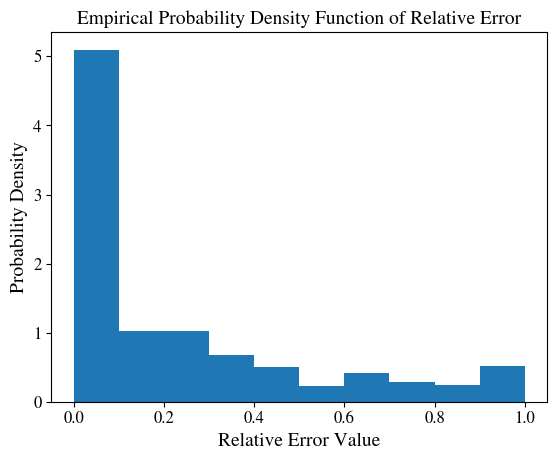

In [53]:
import matplotlib.pyplot as plt  # type: ignore

plt.hist(relative_errors, bins=10, range=(0, 1), density=True,)# cumulative=True)# edgecolor="black")
plt.xlabel("Relative Error Value")
plt.ylabel("Probability Density")
plt.title("Empirical Probability Density Function of Relative Error")
plt.show()

### Create Visualization of an Episode with Network, Optimal Solution, and Agent Solution

#### Code

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import display

# Note: For the interactive plotter to work, you must enable the widget backend.
# Run `%matplotlib widget` in a separate cell or uncomment the line below.
# %matplotlib widget

def plot_network_with_edge_annotations(nodes, edges, obs, env, 
                                     all_optimal_interdiction_edges, episode,
                                     title="Network with Edge Characteristics",
                                     figsize=(14, 8), optimal_edges=None):
    """
    Plot network with edge widths based on capacity and annotations for costs/probabilities.
    """
    
    # Extract edge characteristics
    edge_capacity = obs['edge_capacity']
    edge_costs = obs['edge_costs']
    edge_interdiction_probability = obs['edge_interdiction_probability']
    budget = obs['budget'][0]

    # Get interdictable edges list (in order)
    interdictable_edges_list = list(env.both_edges)
    
    # Get optimal interdiction edges for this episode
    if optimal_edges == None:
        optimal_edges = all_optimal_interdiction_edges[episode] if episode < len(all_optimal_interdiction_edges) else set()

    # --- MEAN FLOW CALCULATION ---
    # Calculate mean flows using the environment's internal method
    # Apply optimal interdictions to the environment state first
    mean_flows = {}
    try:
        current_strategy = env.attacker_strategy if hasattr(env, 'attacker_strategy') else "zero_sum"
        
        # Backup current interdiction state
        original_interdicted = None
        if hasattr(env, 'state') and 'edge_interdicted' in env.state:
            original_interdicted = env.state['edge_interdicted'].copy()
            
            # Apply optimal interdictions
            new_interdicted = np.zeros_like(env.state['edge_interdicted'])
            
            edges_to_simulate = optimal_edges
            if isinstance(optimal_edges, dict):
                # Default background flow simulation to just the optimal plan
                edges_to_simulate = optimal_edges.get('optimal', [])
                
            for edge in edges_to_simulate:
                if edge in env.edge_to_index:
                    idx = env.edge_to_index[edge]
                    new_interdicted[idx] = 1
                elif (edge[1], edge[0]) in env.edge_to_index:
                    idx = env.edge_to_index[(edge[1], edge[0])]
                    new_interdicted[idx] = 1
            
            env.state['edge_interdicted'] = new_interdicted
        
        # We need full flows to get flow values on edges
        _, mean_flows_res = env._calculate_stochastic_objective_and_flow(strategy_type=current_strategy, return_full_flows=True)
        
        # Convert NumPy array to dictionary for downstream plotting code compatibility
        if isinstance(mean_flows_res, np.ndarray):
            mean_flows = {edge: mean_flows_res[i] for i, edge in enumerate(env.both_edges)}
        else:
            mean_flows = mean_flows_res

        obj, _ = env._calculate_canalize_objective_and_flows()
        
        print("Objective: ", obj)
        
        # Restore interdiction state
        if original_interdicted is not None:
            env.state['edge_interdicted'] = original_interdicted
            
    except Exception as e:
        print(f"Warning: Could not calculate mean flows: {e}")
        try:
             if 'original_interdicted' in locals() and original_interdicted is not None:
                env.state['edge_interdicted'] = original_interdicted
        except:
            pass
        mean_flows = {}
    
    # Identify strategies
    canalize_target_edges = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "canalize" and 
        hasattr(env, 'state') and 'canalize_objective' in env.state):
        for i, edge_id in enumerate(interdictable_edges_list):
            if (i < len(env.state['canalize_objective']) and env.state['canalize_objective'][i] == 1):
                canalize_target_edges.add(edge_id)
    
    isolate_target_edges = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "isolate" and 
        hasattr(env, 'state') and 'isolate_objective' in env.state):
        for i, edge_id in enumerate(interdictable_edges_list):
            if (i < len(env.state['isolate_objective']) and env.state['isolate_objective'][i] == 1):
                isolate_target_edges.add(edge_id)
    
    divert_to_target_edges = set()
    divert_from_target_edges = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "divert" and hasattr(env, 'state')):
        if 'divert_to_objective' in env.state:
            for i, edge_id in enumerate(interdictable_edges_list):
                if (i < len(env.state['divert_to_objective']) and env.state['divert_to_objective'][i] == 1):
                    divert_to_target_edges.add(edge_id)
        if 'divert_from_objective' in env.state:
            for i, edge_id in enumerate(interdictable_edges_list):
                if (i < len(env.state['divert_from_objective']) and env.state['divert_from_objective'][i] == 1):
                    divert_from_target_edges.add(edge_id)
    
    # Create Graph
    G = nx.Graph()
    source_nodes, sink_nodes = set(), set()
    for node_id, node_obj in nodes.items():
        if node_obj.node_type == 'source': source_nodes.add(node_id)
        elif node_obj.node_type == 'sink': sink_nodes.add(node_id)
    
    nodes_to_display = {}
    for node_id, node_obj in nodes.items():
        if node_obj.node_type not in ['source', 'sink']:
            G.add_node(node_id, pos=(node_obj.xpos, node_obj.ypos), node_type=node_obj.node_type)
            nodes_to_display[node_id] = node_obj
            
    nodes_connected_to_source, nodes_connected_to_sink = set(), set()
    for edge_id, edge_obj in edges.items():
        o, d = edge_id
        if o in source_nodes and d in nodes_to_display: nodes_connected_to_source.add(d)
        elif d in sink_nodes and o in nodes_to_display: nodes_connected_to_sink.add(o)

    edge_capacity_map = {eid: edge_capacity[i] for i, eid in enumerate(interdictable_edges_list)}
    edge_costs_map = {eid: edge_costs[i] for i, eid in enumerate(interdictable_edges_list)}
    edge_prob_map = {eid: edge_interdiction_probability[i] for i, eid in enumerate(interdictable_edges_list)}
    
    for edge_id, edge_obj in edges.items():
        o, d = edge_id
        if o in nodes_to_display and d in nodes_to_display:
            G.add_edge(o, d,
                       interdictable=edge_obj.interdictable,
                       capacity=edge_capacity_map.get(edge_id, 1.0),
                       cost=edge_costs_map.get(edge_id, 0.0),
                       probability=edge_prob_map.get(edge_id, 0.0))
    
    # Use fig, ax for better control
    fig, ax = plt.subplots(figsize=figsize)
    pos = nx.get_node_attributes(G, 'pos')
    type_color_map = {'source_connected': '#ADB94C', 'intermediate': '#7BB6D0', 'sink_connected': '#E0B410'}
    
    # Draw Nodes
    for nlist, color in [([n for n in G.nodes if n in nodes_connected_to_source], 'source_connected'),
                         ([n for n in G.nodes if n in nodes_connected_to_sink], 'sink_connected'),
                         ([n for n in G.nodes if n not in nodes_connected_to_source and n not in nodes_connected_to_sink], 'intermediate')]:
        if nlist:
            nx.draw_networkx_nodes(G, pos, nodelist=nlist, node_color=type_color_map[color], node_size=800, edgecolors='black', linewidths=1, ax=ax)
            
    # Draw Edges
    interdictable = [(u, v) for u, v, d in G.edges(data=True) if d['interdictable']]
    non_interdictable = [(u, v) for u, v, d in G.edges(data=True) if not d['interdictable']]
    
    strategy_edges = set()
    special_groups = [
        (canalize_target_edges, 'limegreen'),
        (isolate_target_edges, 'red'),
        (divert_to_target_edges, 'limegreen'),
        (divert_from_target_edges, 'red')
    ]
    
    # Helper functions
    min_c, max_c = 30, 60
    def get_w(cap): return (7 + 7*((cap-min_c)/(max_c-min_c))) if max_c > min_c else 4.0
    def get_w_spec(cap): return (4 + 10*((cap-min_c)/(max_c-min_c))) if max_c > min_c else 4.0
    
    # Draw Special Edges
    for target_set, color in special_groups:
        if target_set:
            current = [(u,v) for u,v in interdictable if (u,v) in target_set or (v,u) in target_set]
            strategy_edges.update(current)
            if current:
                w = [get_w_spec(G[u][v]['capacity']) for u,v in current]
                a = [1.0 - 0.8*G[u][v]['probability'] for u,v in current]
                for i, (u,v) in enumerate(current):
                    nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i], edge_color='black', alpha=a[i], ax=ax)
                    nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i]-3, edge_color=color, alpha=1, ax=ax)

    # Draw Regular Edges
    regular = [(u,v) for u,v in interdictable if (u,v) not in strategy_edges and (v,u) not in strategy_edges]
    if regular:
        w = [get_w(G[u][v]['capacity']) for u,v in regular]
        a = [1.0 - 0.8*G[u][v]['probability'] for u,v in regular]
        for i, (u,v) in enumerate(regular):
            nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i], edge_color='black', alpha=a[i], ax=ax)
            nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i]-3, edge_color='white', alpha=1, ax=ax)

    if non_interdictable:
        nx.draw_networkx_edges(G, pos, edgelist=non_interdictable, width=2, edge_color='gray', alpha=0.5, ax=ax)

    # Draw Mean Flows
    if mean_flows:
        for u, v in G.edges():
            flow_val = mean_flows.get((u, v), 0) + mean_flows.get((v, u), 0)
            if flow_val > 0.01:
                capacity = G[u][v]['capacity']
                is_special = (u,v) in strategy_edges or (v,u) in strategy_edges
                outer_w = get_w_spec(capacity) if is_special else get_w(capacity)
                inner_w = max(0.5, outer_w - 3)
                flow_w = min(inner_w, inner_w * (flow_val/capacity)) if capacity > 0 else 0
                if flow_w > 0.1:
                    nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=flow_w, edge_color='blue', alpha=0.7, ax=ax)

    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax)
    
    # Cost Labels
    for u, v, d in G.edges(data=True):
        if d['interdictable']:
            u_pos, v_pos = pos[u], pos[v]
            mid_x, mid_y = (u_pos[0]+v_pos[0])/2, (u_pos[1]+v_pos[1])/2
            dx, dy = v_pos[0]-u_pos[0], v_pos[1]-u_pos[1]
            L = np.sqrt(dx**2+dy**2)
            if L>0:
                px, py = -dy/L, dx/L
                ax.text(mid_x+0.1*px, mid_y+0.1*py, f"{int(d['cost'])}", fontsize=14, color='red', ha='center', va='center', fontweight='bold')

    # Optimal Markers
    x_c, y_c = [], []
    if optimal_edges:
        x_c_opt, y_c_opt = [], []
        
        # Check if we have RL_classify multi-variable dict
        if isinstance(optimal_edges, dict):
            # Parse different edge sets
            opt_set = optimal_edges.get('optimal', [])
            rl_set = optimal_edges.get('rl', [])
            min_cut_set = optimal_edges.get('min_cut', [])
            max_flow_set = optimal_edges.get('max_flow', [])
            
            # Helper to plot markers with optional offset 
            def plot_markers(edge_set, marker_type, color, size, offset_x=0, offset_y=0):
                x_vals, y_vals = [], []
                for edge_id in edge_set:
                    if edge_id in G.edges():
                        u, v = edge_id
                        x_vals.append((pos[u][0]+pos[v][0])/2 + offset_x)
                        y_vals.append((pos[u][1]+pos[v][1])/2 + offset_y)
                if x_vals:
                    ax.scatter(x_vals, y_vals, marker=marker_type, s=size, c=color, linewidths=4, zorder=10)
            
            # Plot each set - slightly offset so they don't completely overlap if identical
            offset_amt = 0.008 * (ax.get_xlim()[1] - ax.get_xlim()[0])
            plot_markers(opt_set, 'x', 'red', 400, 0, 0)
            plot_markers(rl_set, '+', 'purple', 450, offset_amt, offset_amt)
            plot_markers(min_cut_set, '1', 'orange', 350, -offset_amt, offset_amt)
            plot_markers(max_flow_set, '2', 'darkcyan', 350, offset_amt, -offset_amt)
            
        else:
            for edge_id in optimal_edges:
                if edge_id in G.edges():
                    u, v = edge_id
                    x_c_opt.append((pos[u][0]+pos[v][0])/2)
                    y_c_opt.append((pos[u][1]+pos[v][1])/2)
            if x_c_opt:
                ax.scatter(x_c_opt, y_c_opt, marker='x', s=400, c='red', linewidths=4, zorder=10)

    # Budget Label
    ax.text(0.98, 1.05, f'Budget: {int(budget)}', transform=ax.transAxes, fontsize=14, color='red', fontweight='bold', ha='right', va='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.axis('off')
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', lw=4, label='Interdictable'),
        Line2D([0], [0], color='blue', lw=2, alpha=0.7, label='Mean Flow'),
    ]
    
    if optimal_edges:
        if isinstance(optimal_edges, dict):
            legend_elements.append(Line2D([0], [0], marker='x', color='red', markersize=12, linestyle='None', label='Optimal Plan'))
            legend_elements.append(Line2D([0], [0], marker='+', color='purple', markersize=12, markeredgewidth=3, linestyle='None', label='RL Agent'))
            legend_elements.append(Line2D([0], [0], marker='1', color='orange', markersize=14, markeredgewidth=3, linestyle='None', label='Min-Cut'))
            legend_elements.append(Line2D([0], [0], marker='2', color='darkcyan', markersize=14, markeredgewidth=3, linestyle='None', label='Max-Flow'))
        else:
            legend_elements.append(Line2D([0], [0], marker='x', color='red', markersize=12, linestyle='None', label='Optimal Plan'))
            
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)
    
    plt.tight_layout()
    plt.show()
    return G

class InteractiveInterdictionPlotter:
    """
    Interactive class to plot network interdictions and update mean flows on click.
    Requires %matplotlib widget backend.
    """
    def __init__(self, nodes, edges, obs, env, all_optimal_interdiction_edges, episode,
                 title="Interactive Network (Click edge to toggle)", figsize=(14, 8)):
        self.nodes = nodes
        self.edges = edges
        self.obs = obs
        self.env = env
        self.episode = episode
        self.title = title
        self.figsize = figsize
        
        # Check backend
        import matplotlib
        backend = matplotlib.get_backend()
        if 'ipympl' not in backend and 'widget' not in backend:
            print(f"Note: Current backend is '{backend}'. For interactivity, use '%matplotlib widget'.")
        
        # Determine initial set of interdicted edges
        self.interdicted_edges_set = set()
        if episode < len(all_optimal_interdiction_edges):
            self.interdicted_edges_set = set(all_optimal_interdiction_edges[episode])
            
        with plt.ioff(): 
            self.fig, self.ax = plt.subplots(figsize=self.figsize)
            
        self.cid = self.fig.canvas.mpl_connect('button_press_event', self.on_click)
        
        self.pos = {}
        self.G = None
        
        self.draw()
        
        display(self.fig)
        
    def draw(self):
        self.ax.clear()
        
        # Extract edge characteristics
        edge_capacity = self.obs['edge_capacity']
        edge_costs = self.obs['edge_costs']
        edge_interdiction_probability = self.obs['edge_interdiction_probability']
        
        interdictable_edges_list = list(self.env.both_edges)
        display_interdicted_edges = self.interdicted_edges_set
        
        # --- MEAN FLOW RE-CALCULATION ---
        mean_flows = {}
        try:
            current_strategy = self.env.attacker_strategy if hasattr(self.env, 'attacker_strategy') else "zero_sum"
            
            original_interdicted = None
            if hasattr(self.env, 'state') and 'edge_interdicted' in self.env.state:
                original_interdicted = self.env.state['edge_interdicted'].copy()
                
                new_interdicted = np.zeros_like(self.env.state['edge_interdicted'])
                for edge in self.interdicted_edges_set:
                    if edge in self.env.edge_to_index:
                        new_interdicted[self.env.edge_to_index[edge]] = 1
                    elif (edge[1], edge[0]) in self.env.edge_to_index:
                        new_interdicted[self.env.edge_to_index[(edge[1], edge[0])]] = 1
                
                self.env.state['edge_interdicted'] = new_interdicted
            
            _, mean_flows_res = self.env._calculate_stochastic_objective_and_flow(strategy_type=current_strategy, return_full_flows=True)
            
            if isinstance(mean_flows_res, np.ndarray):
                mean_flows = {edge: mean_flows_res[i] for i, edge in enumerate(self.env.both_edges)}
            else:
                mean_flows = mean_flows_res
            
            if original_interdicted is not None:
                self.env.state['edge_interdicted'] = original_interdicted
                
        except Exception as e:
            print(f"Flow Calc Warning: {e}")
            try:
                if 'original_interdicted' in locals() and original_interdicted is not None:
                     self.env.state['edge_interdicted'] = original_interdicted
            except: pass
        
        # Strategy Ident
        canalize_target_edges = set()
        if (hasattr(self.env, 'attacker_strategy') and self.env.attacker_strategy == "canalize" and hasattr(self.env, 'state') and 'canalize_objective' in self.env.state):
            for i, edge_id in enumerate(list(self.env.both_edges)):
                 if i < len(self.env.state['canalize_objective']) and self.env.state['canalize_objective'][i] == 1: canalize_target_edges.add(edge_id)
        
        isolate_target_edges = set()
        if (hasattr(self.env, 'attacker_strategy') and self.env.attacker_strategy == "isolate" and hasattr(self.env, 'state') and 'isolate_objective' in self.env.state):
            for i, edge_id in enumerate(list(self.env.both_edges)):
                 if i < len(self.env.state['isolate_objective']) and self.env.state['isolate_objective'][i] == 1: isolate_target_edges.add(edge_id)
                     
        divert_to_edges, divert_from_edges = set(), set()
        if (hasattr(self.env, 'attacker_strategy') and self.env.attacker_strategy == "divert" and hasattr(self.env, 'state')):
             if 'divert_to_objective' in self.env.state:
                 for i, edge_id in enumerate(list(self.env.both_edges)):
                     if i < len(self.env.state['divert_to_objective']) and self.env.state['divert_to_objective'][i] == 1: divert_to_edges.add(edge_id)
             if 'divert_from_objective' in self.env.state:
                 for i, edge_id in enumerate(list(self.env.both_edges)):
                     if i < len(self.env.state['divert_from_objective']) and self.env.state['divert_from_objective'][i] == 1: divert_from_edges.add(edge_id)

        # Build Graph
        G = nx.Graph()
        source_nodes, sink_nodes = set(), set()
        nodes_to_display = {}
        for node_id, node_obj in self.nodes.items():
            if node_obj.node_type == 'source': source_nodes.add(node_id)
            elif node_obj.node_type == 'sink': sink_nodes.add(node_id)
            else:
                G.add_node(node_id, pos=(node_obj.xpos, node_obj.ypos), node_type=node_obj.node_type)
                nodes_to_display[node_id] = node_obj
        
        edge_capacity_map = {eid: edge_capacity[i] for i, eid in enumerate(interdictable_edges_list)}
        edge_costs_map = {eid: edge_costs[i] for i, eid in enumerate(interdictable_edges_list)}
        edge_prob_map = {eid: edge_interdiction_probability[i] for i, eid in enumerate(interdictable_edges_list)}
        
        for edge_id, edge_obj in self.edges.items():
            u, v = edge_id
            if u in nodes_to_display and v in nodes_to_display:
                G.add_edge(u, v, interdictable=edge_obj.interdictable,
                           capacity=edge_capacity_map.get(edge_id, 1.0),
                           cost=edge_costs_map.get(edge_id, 0.0),
                           probability=edge_prob_map.get(edge_id, 0.0))
        
        self.G = G
        self.pos = nx.get_node_attributes(G, 'pos')
        pos = self.pos
        
        # Draw Nodes
        type_color_map = {'source_connected': '#ADB94C', 'intermediate': '#7BB6D0', 'sink_connected': '#E0B410'}
        nodes_conn_source = set()
        nodes_conn_sink = set()
        for edge_id in self.edges:
            u,v = edge_id
            if u in source_nodes and v in nodes_to_display: nodes_conn_source.add(v)
            elif v in sink_nodes and u in nodes_to_display: nodes_conn_sink.add(u)
            
        nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G.nodes if n in nodes_conn_source], node_color=type_color_map['source_connected'], node_size=800, edgecolors='black', ax=self.ax)
        nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G.nodes if n in nodes_conn_sink], node_color=type_color_map['sink_connected'], node_size=800, edgecolors='black', ax=self.ax)
        nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G.nodes if n not in nodes_conn_source and n not in nodes_conn_sink], node_color=type_color_map['intermediate'], node_size=800, edgecolors='black', ax=self.ax)
        
        # Draw Edges
        interdictable = [(u, v) for u, v, d in G.edges(data=True) if d['interdictable']]
        non_interdictable = [(u, v) for u, v, d in G.edges(data=True) if not d['interdictable']]
        
        specials = {
            'canalize': (canalize_target_edges, 'limegreen'),
            'isolate': (isolate_target_edges, 'red'),
            'divert_to': (divert_to_edges, 'limegreen'),
            'divert_from': (divert_from_edges, 'red')
        }
        
        special_edges = set()
        for k, (s, c) in specials.items():
            special_edges.update([(u,v) for u,v in interdictable if (u,v) in s or (v,u) in s])

        min_c, max_c = 30, 60
        def get_w(cap): return (7 + 7*((cap-min_c)/(max_c-min_c))) if max_c > min_c else 4.0
        def get_w_spec(cap): return (4 + 10*((cap-min_c)/(max_c-min_c))) if max_c > min_c else 4.0
        
        # Draw Regular
        regular = [(u,v) for u,v in interdictable if (u,v) not in special_edges and (v,u) not in special_edges]
        if regular:
            w = [get_w(G[u][v]['capacity']) for u,v in regular]
            a = [1.0 - 0.8*G[u][v]['probability'] for u,v in regular]
            for i, (u,v) in enumerate(regular):
                nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i], edge_color='black', alpha=a[i], ax=self.ax)
                nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i]-3, edge_color='white', alpha=1, ax=self.ax)

        # Draw Special
        for k, (s, color) in specials.items():
            current = [(u,v) for u,v in interdictable if (u,v) in s or (v,u) in s]
            if current:
                w = [get_w_spec(G[u][v]['capacity']) for u,v in current]
                a = [1.0 - 0.8*G[u][v]['probability'] for u,v in current]
                for i, (u,v) in enumerate(current):
                    nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i], edge_color='black', alpha=a[i], ax=self.ax)
                    nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w[i]-3, edge_color=color, alpha=1, ax=self.ax)

        if non_interdictable:
            nx.draw_networkx_edges(G, pos, edgelist=non_interdictable, width=2, edge_color='gray', alpha=0.5, ax=self.ax)

        # Draw Mean Flows
        if mean_flows:
            for u,v in G.edges():
                flow_val = mean_flows.get((u,v), 0) + mean_flows.get((v,u), 0)
                if flow_val > 0.01:
                    capacity = G[u][v]['capacity']
                    is_spec = (u,v) in special_edges or (v,u) in special_edges
                    outer_w = get_w_spec(capacity) if is_spec else get_w(capacity)
                    inner_w = max(0.5, outer_w - 3)
                    flow_w = min(inner_w, inner_w * (flow_val/capacity)) if capacity > 0 else 0
                    if flow_w > 0.1:
                        nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=flow_w, edge_color='blue', alpha=0.7, ax=self.ax)

        nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=self.ax)
        
        # Costs
        for u, v, d in G.edges(data=True):
            if d['interdictable']:
                u_pos, v_pos = pos[u], pos[v]
                mid_x, mid_y = (u_pos[0]+v_pos[0])/2, (u_pos[1]+v_pos[1])/2
                dx, dy = v_pos[0]-u_pos[0], v_pos[1]-u_pos[1]
                L = np.sqrt(dx**2+dy**2)
                if L>0:
                    px, py = -dy/L, dx/L
                    self.ax.text(mid_x+0.1*px, mid_y+0.1*py, f"{int(d['cost'])}", fontsize=14, color='red', ha='center', va='center', fontweight='bold')

        # Interdicted X
        x_c, y_c = [], []
        for edge_id in display_interdicted_edges:
            if edge_id in G.edges():
                u, v = edge_id
                x_c.append((pos[u][0]+pos[v][0])/2)
                y_c.append((pos[u][1]+pos[v][1])/2)
        if x_c:
            self.ax.scatter(x_c, y_c, marker='x', s=400, c='red', linewidths=4, zorder=10)
            
        self.ax.set_title(self.title, fontsize=16, fontweight='bold')
        self.ax.axis('off')
        # Explicit draw() call to ensure update
        self.fig.canvas.draw_idle()
        
    def on_click(self, event):
        if event.inaxes != self.ax: return
        x, y = event.xdata, event.ydata
        
        min_dist = float('inf')
        closest_edge = None
        xlim = self.ax.get_xlim()
        threshold = (xlim[1] - xlim[0]) * 0.03
        
        for u, v, d in self.G.edges(data=True):
            if d['interdictable']:
                 u_pos, v_pos = self.pos[u], self.pos[v]
                 px, py = u_pos
                 qx, qy = v_pos
                 l2 = (qx-px)**2 + (qy-py)**2
                 if l2 == 0: dist = np.sqrt((x-px)**2 + (y-py)**2)
                 else:
                     t = max(0, min(1, ((x-px)*(qx-px) + (y-py)*(qy-py)) / l2))
                     dist = np.sqrt((x-(px+t*(qx-px)))**2 + (y-(py+t*(qy-py)))**2)
                 
                 if dist < min_dist:
                     min_dist = dist
                     closest_edge = (u, v)
        
        if min_dist < threshold and closest_edge:
            u, v = closest_edge
            edge_key = (u,v)
            if edge_key not in self.env.edge_to_index: edge_key = (v,u)
            
            if edge_key in self.interdicted_edges_set: self.interdicted_edges_set.remove(edge_key)
            else: self.interdicted_edges_set.add(edge_key)
            self.draw()

#### Plot

None
Optimal Interdictions:  [(2, 7), (10, 15), (13, 14), (14, 19), (16, 21)]
Agent Interdictions:  [(9, 14), (9, 10), (2, 7), (13, 14), (14, 19)]
Objective:  13.030945011068535


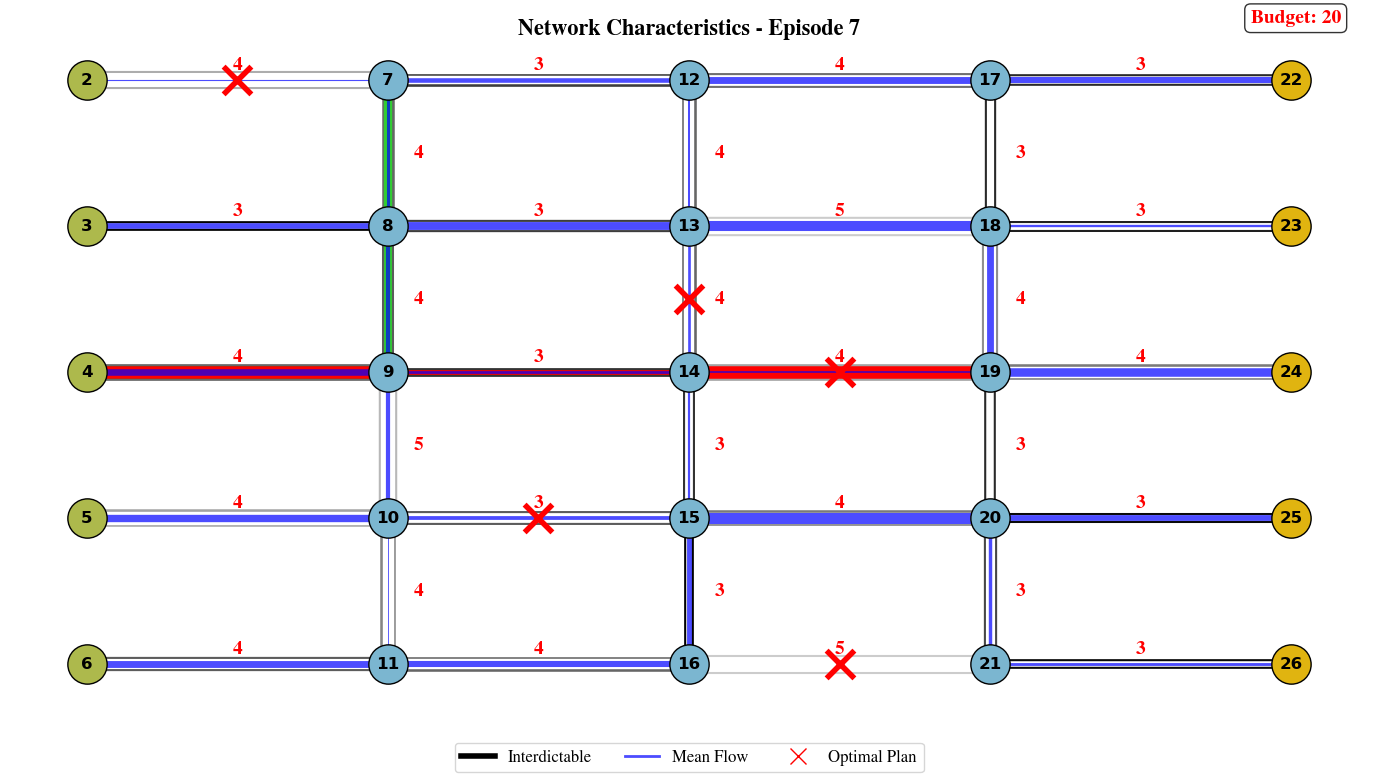

13.030945011068535
78.7257260598708  sec
ENVIRONMENT STATE (Non-padded values only)
Actual number of edges in graph: 42

                               Budget Information                               
--------------------------------------------------------------------------------
Remaining / Reference Budget: 20 / 20

                             Edge State Information                             
--------------------------------------------------------------------------------
Index    Origin   Dest     Capacity     Cost     Int. Prob    Interdicted 
--------------------------------------------------------------------------------
0        1        2        30           4        0.00         0           
1        1        3        30           4        0.00         0           
2        1        4        30           4        0.00         0           
3        1        5        30           3        0.00         0           
4        1        6        30           3        0.00       

In [ ]:
# Usage with your code:
episode =7
obs, _ = env.load_network_from_state(seed=None, state=all_states[episode][0])
print("Reference Flow:", env.reference_start_flow)
edge_capacity = obs['edge_capacity']
edge_costs = obs['edge_costs']
edge_interdiction_probability = obs['edge_interdiction_probability']

# Plot the network with optimal interdiction edges marked
if method_type == 'RL' and RL_classify:
    # Get heuristic actions for this specific episode again
    env_state = copy.deepcopy(all_states[episode][0])
    obs, _ = env.load_network_from_state(episode, copy.deepcopy(env_state))
    min_cut_objVal, min_cut_actions = env.solve_min_cut_heuristic()
    
    obs, _ = env.load_network_from_state(episode, copy.deepcopy(env_state))
    max_flow_objVal, max_flow_actions = env.solve_heuristic_interdiction()
    
    optimal_edges = {
        'optimal': all_optimal_interdiction_edges[episode],
        'rl': all_agent_actions[episode],
        'min_cut': min_cut_actions,
        'max_flow': max_flow_actions
    }
    
    print("\n--- Episode {} Results ---".format(episode))
    print(f"Optimal Interdictions : {all_optimal_interdiction_edges[episode]}")
    print(f"Optimal Objective     : {optimal_obj_vals[episode]}")
    
    print(f"\nRL Agent Interdictions: {all_agent_actions[episode]}")
    print(f"RL Agent Objective    : {agent_best_rewards[episode]}")
    print(f"RL Agent Rel. Error   : {relative_errors[episode]:.4f}")
    
    # Calculate dummy relative errors for heuristics strictly for print display
    ref_obj = reference_objs[episode]
    opt_obj = optimal_obj_vals[episode]
    
    def calc_rel_error(val, ref, opt, strat, empty_action=False):
        if empty_action and np.isnan(val): return 0.0
        if np.isnan(val): return 1.0 # Failed but took action
        if strat == "zero_sum":
            if ref == opt: return 0.0
            return max(0, val - opt) / (ref - opt)
        elif strat in ["canalize", "divert"]:
            denom = abs(ref - opt)
            if denom == 0: return 0.0
            return min(1.0, abs(val - opt) / denom)
        elif strat == "isolate":
            if ref == opt: return 0.0
            return max(0, ((ref - opt) - (ref - val)) / (ref - opt))
        return 0.0
        
    mc_err = calc_rel_error(min_cut_objVal, ref_obj, opt_obj, env_params['attacker_strategy'], len(min_cut_actions)==0)
    mf_err = calc_rel_error(max_flow_objVal, ref_obj, opt_obj, env_params['attacker_strategy'], len(max_flow_actions)==0)
    
    print(f"\nMin-Cut Interdictions : {min_cut_actions}")
    print(f"Min-Cut Objective     : {min_cut_objVal}")
    print(f"Min-Cut Rel. Error    : {mc_err:.4f}")
    
    print(f"\nMax-Flow Interdictions: {max_flow_actions}")
    print(f"Max-Flow Objective    : {max_flow_objVal}")
    print(f"Max-Flow Rel. Error   : {mf_err:.4f}")
    print("--------------------------\n")
    
else:
    optimal_edges = all_optimal_interdiction_edges[episode]
    print(f"Optimal Interdictions: {all_optimal_interdiction_edges[episode]}")
    print(f"Optimal Objective    : {optimal_obj_vals[episode]}")
    print(f"Agent Interdictions  : {all_agent_actions[episode]}")
    print(f"Agent Objective      : {agent_best_rewards[episode]}")
    print(f"Agent Rel. Error     : {relative_errors[episode]:.4f}")

G = plot_network_with_edge_annotations(nodes, edges, obs, env, 
                                     all_optimal_interdiction_edges, episode,
                                     title=f"Network Characteristics - Episode {episode}", optimal_edges=optimal_edges)

env.render(indices = 41)

In [31]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import warnings

# Try to import Plotly/Widgets for interactive version
try:
    import plotly.graph_objects as go
    import ipywidgets as widgets
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False
    print("Warning: 'plotly' and 'ipywidgets' are required for the interactive plotter. Please install them.")

def plot_network_with_edge_annotations(nodes, edges, obs, env, 
                                     all_optimal_interdiction_edges, episode,
                                     title="Network with Edge Characteristics",
                                     figsize=(14, 8)):
    """
    Static Matplotlib Plotter.
    Plots network with edge annotations, mean flows, and optimal interdiction plan using standard Matplotlib.
    This produces a static image.
    """
    
    # Extract edge characteristics
    edge_capacity = obs['edge_capacity']
    edge_costs = obs['edge_costs']
    edge_interdiction_probability = obs['edge_interdiction_probability']
    budget = obs['budget'][0]

    interdictable_edges_list = list(env.both_edges)
    
    # Get optimal interdiction edges for this episode
    optimal_edges = all_optimal_interdiction_edges[episode] if episode < len(all_optimal_interdiction_edges) else set()

    # --- MEAN FLOW CALCULATION ---
    mean_flows = {}
    try:
        current_strategy = env.attacker_strategy if hasattr(env, 'attacker_strategy') else "zero_sum"
        
        # Backup and Apply Interdictions
        original_interdicted = None
        if hasattr(env, 'state') and 'edge_interdicted' in env.state:
            original_interdicted = env.state['edge_interdicted'].copy()
            new_interdicted = np.zeros_like(env.state['edge_interdicted'])
            for edge in optimal_edges:
                if edge in env.edge_to_index:
                    new_interdicted[env.edge_to_index[edge]] = 1
                elif (edge[1], edge[0]) in env.edge_to_index:
                    new_interdicted[env.edge_to_index[(edge[1], edge[0])]] = 1
            env.state['edge_interdicted'] = new_interdicted
        
        # Calculate Flows
        _, mean_flows = env._calculate_stochastic_objective_and_flow(strategy_type=current_strategy, return_full_flows=True)
        
        # Restore
        if original_interdicted is not None:
            env.state['edge_interdicted'] = original_interdicted
            
    except Exception as e:
        print(f"Static Plot Flow Warning: {e}")
        try:
             if 'original_interdicted' in locals() and original_interdicted is not None:
                env.state['edge_interdicted'] = original_interdicted
        except: pass
        mean_flows = {}
    
    # Identify strategies
    canalize_target_edges = set()
    isolate_target_edges = set()
    divert_to_edges = set()
    divert_from_edges = set()
    
    s = env.state if hasattr(env, 'state') else {}
    if hasattr(env, 'attacker_strategy'):
        strat = env.attacker_strategy
        if strat == "canalize" and 'canalize_objective' in s:
            canalize_target_edges = {eid for i, eid in enumerate(interdictable_edges_list) if i < len(s['canalize_objective']) and s['canalize_objective'][i] == 1}
        elif strat == "isolate" and 'isolate_objective' in s:
            isolate_target_edges = {eid for i, eid in enumerate(interdictable_edges_list) if i < len(s['isolate_objective']) and s['isolate_objective'][i] == 1}
        elif strat == "divert":
            if 'divert_to_objective' in s:
                divert_to_edges = {eid for i, eid in enumerate(interdictable_edges_list) if i < len(s['divert_to_objective']) and s['divert_to_objective'][i] == 1}
            if 'divert_from_objective' in s:
                divert_from_edges = {eid for i, eid in enumerate(interdictable_edges_list) if i < len(s['divert_from_objective']) and s['divert_from_objective'][i] == 1}

    # Build Graph
    G = nx.Graph()
    source_nodes = {nid for nid, n in nodes.items() if n.node_type == 'source'}
    sink_nodes = {nid for nid, n in nodes.items() if n.node_type == 'sink'}
    
    nodes_to_display = {nid: n for nid, n in nodes.items() if nid not in source_nodes and nid not in sink_nodes}
    for nid, n in nodes_to_display.items():
        G.add_node(nid, pos=(n.xpos, n.ypos))

    edge_maps = {
        'capacity': {eid: edge_capacity[i] for i, eid in enumerate(interdictable_edges_list)},
        'cost': {eid: edge_costs[i] for i, eid in enumerate(interdictable_edges_list)},
        'prob': {eid: edge_interdiction_probability[i] for i, eid in enumerate(interdictable_edges_list)}
    }

    for edge_id, edge_obj in edges.items():
        o, d = edge_id
        if o in nodes_to_display and d in nodes_to_display:
            G.add_edge(o, d, 
                       interdictable=edge_obj.interdictable,
                       capacity=edge_maps['capacity'].get(edge_id, 1),
                       cost=edge_maps['cost'].get(edge_id, 0),
                       probability=edge_maps['prob'].get(edge_id, 0))

    # Plotting
    fig, ax = plt.subplots(figsize=figsize)
    pos = nx.get_node_attributes(G, 'pos')
    
    # Draw Nodes
    conn_source = {d for o, d in edges.keys() if o in source_nodes and d in nodes_to_display}
    conn_sink = {o for o, d in edges.keys() if d in sink_nodes and o in nodes_to_display}
    
    colors = {'src': '#ADB94C', 'sink': '#E0B410', 'mid': '#7BB6D0'}
    for grp, color in [(conn_source, 'src'), (conn_sink, 'sink'), (set(G.nodes)-conn_source-conn_sink, 'mid')]:
        if grp: nx.draw_networkx_nodes(G, pos, nodelist=list(grp), node_color=colors[color], node_size=800, edgecolors='black', ax=ax)

    # Helper for width
    min_c, max_c = 30, 60
    def get_w(cap, special=False): 
        base = 7 if not special else 4
        slope = 7 if not special else 10
        norm = (cap - min_c)/(max_c - min_c) if max_c > min_c else 0
        return base + slope * max(0, min(1, norm))

    # Draw Edges (Background/Context)
    interdictable = [(u, v) for u, v, d in G.edges(data=True) if d['interdictable']]
    non_interdictable = [(u, v) for u, v, d in G.edges(data=True) if not d['interdictable']]

    strategy_colors = {
        'canalize': (canalize_target_edges, 'limegreen'),
        'isolate': (isolate_target_edges, 'red'),
        'divert_to': (divert_to_edges, 'limegreen'),
        'divert_from': (divert_from_edges, 'red')
    }
    
    processed_strat_edges = set()
    
    # Draw Strategy Edges
    for s_name, (target_set, color) in strategy_colors.items():
        current = [(u,v) for u,v in interdictable if (u,v) in target_set or (v,u) in target_set]
        processed_strat_edges.update(current)
        if current:
            ws = [get_w(G[u][v]['capacity'], True) for u,v in current]
            pw = [G[u][v]['probability'] for u,v in current]
            for i, (u,v) in enumerate(current):
                nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=ws[i], edge_color='black', alpha=1-0.8*pw[i], ax=ax)
                nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=ws[i]-3, edge_color=color, alpha=1, ax=ax)

    # Draw Regular Edges
    regular = [(u,v) for u,v in interdictable if (u,v) not in processed_strat_edges and (v,u) not in processed_strat_edges]
    if regular:
        ws = [get_w(G[u][v]['capacity'], False) for u,v in regular]
        pw = [G[u][v]['probability'] for u,v in regular]
        for i, (u,v) in enumerate(regular):
            nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=ws[i], edge_color='black', alpha=1-0.8*pw[i], ax=ax)
            nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=ws[i]-3, edge_color='white', alpha=1, ax=ax)

    if non_interdictable:
        nx.draw_networkx_edges(G, pos, edgelist=non_interdictable, width=2, edge_color='gray', alpha=0.5, ax=ax)

    # Draw Mean Flows
    if mean_flows:
        for u, v in G.edges():
            flow_val = mean_flows.get((u, v), 0) + mean_flows.get((v, u), 0)
            if flow_val > 0.01:
                cap = G[u][v]['capacity']
                is_spec = (u,v) in processed_strat_edges or (v,u) in processed_strat_edges
                outer = get_w(cap, is_spec)
                inner = max(0.5, outer - 3)
                w = min(inner, inner * (flow_val/cap)) if cap > 0 else 0
                if w > 0.1:
                    nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w, edge_color='blue', alpha=0.7, ax=ax)

    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax)
    
    # Costs
    for u, v, d in G.edges(data=True):
        if d['interdictable']:
            p1, p2 = np.array(pos[u]), np.array(pos[v])
            mid = (p1+p2)/2
            vec = p2-p1
            L = np.linalg.norm(vec)
            if L > 0:
                orth = np.array([-vec[1], vec[0]]) / L
                txt_pos = mid + 0.1 * orth
                ax.text(txt_pos[0], txt_pos[1], f"{int(d['cost'])}", color='red', fontsize=14, fontweight='bold', ha='center', va='center')

    # Optimal Markers
    for edge in optimal_edges:
        if edge in G.edges():
            p1, p2 = np.array(pos[edge[0]]), np.array(pos[edge[1]])
            mid = (p1+p2)/2
            ax.scatter(mid[0], mid[1], marker='x', s=400, c='red', linewidths=4, zorder=10)

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    return G

class PlotlyInterdictionPlotter:
    """
    Robust interactive plotter using Plotly + IPyWidgets.
    Does not rely on ipympl/matplotlib-widget.
    Supports clicking 'handles' on edges to toggle interdiction and recomputing flows.
    """
    def __init__(self, nodes, edges, obs, env, all_optimal_interdiction_edges, episode, title="Interactive Network (Plotly)"):
        if not HAS_PLOTLY:
            print("Error: Plotly not installed.")
            return

        self.nodes = nodes
        self.edges = edges
        self.obs = obs
        self.env = env
        self.episode = episode
        self.title = title
        
        # Initial State
        self.interdicted_set = set()
        if episode < len(all_optimal_interdiction_edges):
            self.interdicted_set = set(all_optimal_interdiction_edges[episode])
            
        # Data Prep
        self.G = self._build_graph()
        self.pos = nx.get_node_attributes(self.G, 'pos')
        self.edge_list = list(self.G.edges(data=True)) # stable order
        self.node_list = list(self.G.nodes())
        
        # Create Widget
        self.figure_widget = go.FigureWidget()
        self.layout_setup()
        self.draw_static_elements() # Nodes, Background Lines (non-reactive)
        self.draw_reactive_elements() # Flow lines, Interdiction Handles
        
        # Setup Layout
        self.out = widgets.Output() # For capturing print/errors
        
        # Save Button
        self.btn_save = widgets.Button(description="Save HTML")
        self.btn_save.on_click(self.save_html)
        
        display(widgets.VBox([self.figure_widget, self.btn_save, self.out]))
        
    def _build_graph(self):
        interdictable_edges_list = list(self.env.both_edges)
        edge_capacity = self.obs['edge_capacity']
        
        G = nx.Graph()
        
        # --- Identify Graph Structure Manually (Robust) ---
        source_nodes = {nid for nid, n in self.nodes.items() if n.node_type == 'source'}
        sink_nodes = {nid for nid, n in self.nodes.items() if n.node_type == 'sink'}
        
        nodes_to_display = {nid: n for nid, n in self.nodes.items() if nid not in source_nodes and nid not in sink_nodes}
        
        # Find connections
        conn_source = {d for o, d in self.edges.keys() if o in source_nodes and d in nodes_to_display}
        conn_sink = {o for o, d in self.edges.keys() if d in sink_nodes and o in nodes_to_display}
        
        for nid, n in nodes_to_display.items():
            ntype = 'mid'
            if nid in conn_source: ntype = 'source' # Connected to source
            elif nid in conn_sink: ntype = 'sink' # Connected to sink
            
            G.add_node(nid, pos=(n.xpos, n.ypos), type=ntype)

        edge_mapping = {eid: {'cap': edge_capacity[i]} for i, eid in enumerate(interdictable_edges_list)}
        
        for edge_id, edge_obj in self.edges.items():
            o, d = edge_id
            if o in nodes_to_display and d in nodes_to_display:
                G.add_edge(o, d, 
                           interdictable=edge_obj.interdictable,
                           capacity=edge_mapping.get(edge_id, {'cap':1})['cap'])
        return G

    def layout_setup(self):
        self.figure_widget.update_layout(
            title=self.title,
            showlegend=False,
            hovermode='closest',
            dragmode='pan', # Default to pan to make clicking easier
            margin=dict(b=20,l=5,r=5,t=40),
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            width=900, height=600,
            plot_bgcolor='white'
        )

    def draw_static_elements(self):
        # Draw Nodes
        node_x, node_y, node_color = [], [], []
        colors = {'source': '#ADB94C', 'sink': '#E0B410', 'mid': '#7BB6D0'}
        for n in self.node_list:
            x, y = self.pos[n]
            node_x.append(x); node_y.append(y)
            ntype = self.G.nodes[n].get('type', 'mid')
            node_color.append(colors.get(ntype, colors['mid']))

        self.figure_widget.add_trace(go.Scatter(
            x=node_x, y=node_y, mode='markers+text',
            marker=dict(size=20, color=node_color, line=dict(width=2, color='black')),
            text=[str(n) for n in self.node_list], textposition="middle center",
            hoverinfo='text', zorder=10
        ))
        
        # Draw "Base" Edges (Black/Grey lines underneath)
        edge_x, edge_y = [], []
        for u, v, d in self.edge_list:
            x0, y0 = self.pos[u]
            x1, y1 = self.pos[v]
            edge_x.extend([x0, x1, None])
            edge_y.extend([y0, y1, None])
            
        self.figure_widget.add_trace(go.Scatter(
            x=edge_x, y=edge_y, mode='lines',
            line=dict(width=4, color='lightgrey'), # Base 'pipe'
            hoverinfo='none'
        ))

    def draw_reactive_elements(self):
        # 1. Compute Flow
        # 2. Draw Flow Lines
        # 3. Draw Interdiction Handles
        
        # Clean up existing reactive traces if any (indices > 1 usually)
        # Since update is hard to replace trace in-place with different size, we batch update data
        
        # Calculate Flow
        mean_flows = self._calc_flows()
        
        # Prepare Flow Lines Data
        flow_x, flow_y = [], []
        
        for u, v, d in self.edge_list:
            f = mean_flows.get((u,v),0) + mean_flows.get((v,u),0)
            if f > 0.1:
                x0, y0 = self.pos[u]
                x1, y1 = self.pos[v]
                flow_x.extend([x0, x1, None])
                flow_y.extend([y0, y1, None])
        
        # Update or Add Flow Trace
        if len(self.figure_widget.data) > 2:
            self.figure_widget.data[2].x = flow_x
            self.figure_widget.data[2].y = flow_y
        else:
             self.figure_widget.add_trace(go.Scatter(
                x=flow_x, y=flow_y, mode='lines',
                line=dict(width=3, color='blue'),
                opacity=0.7, name='Flow'
            ))

        # Prepare Handles (Clickable targets midpoint)
        hx, hy, hcolor, hsymbol, htext = [], [], [], [], []
        
        for u, v, d in self.edge_list:
            if d['interdictable']:
                x0, y0 = self.pos[u]
                x1, y1 = self.pos[v]
                hx.append((x0+x1)/2)
                hy.append((y0+y1)/2)
                
                # Check mapping
                key = (u,v)
                if key not in self.env.edge_to_index: key = (v,u)
                
                is_interdicted = key in self.interdicted_set
                hsymbol.append('x' if is_interdicted else 'circle')
                hcolor.append('red' if is_interdicted else 'rgba(0,0,0,0.1)') # faint circle if not
                htext.append(f"Edge {key}<br>Click to Toggle")

        if len(self.figure_widget.data) > 3:
             with self.figure_widget.batch_update():
                self.figure_widget.data[3].x = hx
                self.figure_widget.data[3].y = hy
                self.figure_widget.data[3].marker.symbol = hsymbol
                self.figure_widget.data[3].marker.color = hcolor
                self.figure_widget.data[3].text = htext
        else:
            # Handles Trace
            handles = go.Scatter(
                x=hx, y=hy, mode='markers',
                marker=dict(size=15, color=hcolor, symbol=hsymbol, line=dict(width=1, color='red')),
                text=htext, hoverinfo='text', name='Handles'
            )
            # Bind Click
            handles.on_click(self.handle_click)
            self.figure_widget.add_trace(handles)

    def _calc_flows(self):
        try:
            # Backup
            orig = None
            if hasattr(self.env, 'state') and 'edge_interdicted' in self.env.state:
                orig = self.env.state['edge_interdicted'].copy()
            
            # Apply
            new_idx = np.zeros_like(self.env.state['edge_interdicted'])
            for edge in self.interdicted_set:
                if edge in self.env.edge_to_index: new_idx[self.env.edge_to_index[edge]] = 1
                elif (edge[1], edge[0]) in self.env.edge_to_index: new_idx[self.env.edge_to_index[(edge[1], edge[0])]] = 1
            self.env.state['edge_interdicted'] = new_idx
            
            # Comp
            strat = self.env.attacker_strategy if hasattr(self.env, 'attacker_strategy') else "zero_sum"
            _, flows = self.env._calculate_stochastic_objective_and_flow(strategy_type=strat, return_full_flows=True)
            
            # Restore
            if orig is not None: self.env.state['edge_interdicted'] = orig
            return flows
        except Exception as e:
            with self.out: print(f"Calc error: {e}")
            return {}

    def handle_click(self, trace, points, selector):
        if not points.point_inds: return
        
        idx = points.point_inds[0]
        # Handles are added for *interdictable* edges in order they appear in edge_list
        interdictable_edges = [e for e in self.edge_list if e[2]['interdictable']]
        
        if idx < len(interdictable_edges):
            u, v, d = interdictable_edges[idx]
            key = (u,v)
            if key not in self.env.edge_to_index: key = (v,u)
            
            if key in self.interdicted_set:
                 self.interdicted_set.remove(key)
            else:
                 self.interdicted_set.add(key)
            
            # Redraw reactive parts
            self.draw_reactive_elements()
    

    def save_html(self, b):
        if HAS_PLOTLY:
            self.figure_widget.write_html("interactive_network_snapshot.html")
            with self.out: print("Saved to interactive_network_snapshot.html")

In [21]:
# --- Interactive Plotter Usage Example ---
episode_idx = 0 

# 1. Ensure 'obs' is defined for the specific episode
# Check if we have pre-computed states to load
if 'all_states' in locals() and len(all_states) > episode_idx:
    # Load specific state from the evaluation history
    state_vals = all_states[episode_idx][0]
    obs, _ = env.load_network_from_state(seed=None, state=state_vals)
else:
    # Fallback: Just reset the environment to a seed
    print(f"Note: 'all_states' not found. Resetting environment with seed {episode_idx}.")
    obs, _ = env.reset(seed=episode_idx)

# 2. Ensure interdiction edges list exists
if 'all_optimal_interdiction_edges' not in locals():
    all_optimal_interdiction_edges = []

# 3. Create the Plotly Plotter
# This variable 'plotter' must be kept referenced to handle callbacks
plotter = PlotlyInterdictionPlotter(nodes, edges, obs, env, all_optimal_interdiction_edges, episode=episode_idx)


    'data': [{'hoverinfo': 'text',
              'marker': {'color': [#ADB94C, #…

In [16]:
env.reset()
env.render()

divert_to_segments: [(2, 7), (7, 8), (8, 3)]
endpoints: [2, 3]
Checking shortcut between 2 and 3: False
Adding candidate: divert_from=[(2, 7), (7, 12), (12, 17)], divert_to=[(2, 7), (7, 8), (8, 3)]
divert_to_segments: [(7, 12), (12, 13), (13, 18)]
endpoints: [7, 18]
Checking shortcut between 7 and 18: False
Adding candidate: divert_from=[(7, 12), (12, 17), (17, 22)], divert_to=[(7, 12), (12, 13), (13, 18)]
ENVIRONMENT STATE (Non-padded values only)
Actual number of edges in graph: 42

                               Budget Information                               
--------------------------------------------------------------------------------
Remaining / Reference Budget: 16 / 16

                             Edge State Information                             
--------------------------------------------------------------------------------
Index    Origin   Dest     Capacity     Cost     Int. Prob    Interdicted 
------------------------------------------------------------------------